##  Predicting Banking Crises in African Countries
**Author:** Feven | Ethiopia  
**Course:** Final Project  
**Dataset:** Africa Economic, Banking and Systemic Crisis Data (1860-2014)

---

## 1. Introduction & Research Question

*Banking crises have had devastating effects on African economies, wiping out savings, destabilizing governments, and setting back development by decades. Countries like Zimbabwe, Nigeria, and Kenya have each experienced severe banking collapses tied to inflation, debt defaults, and currency crashes.*

**Research Question:**  
> *What economic indicators are most associated with banking crises in African countries, and can we build a model to predict when a banking crisis is likely to occur?*

**Hypothesis:**  
> Countries with high inflation, sovereign debt defaults, and currency crises will be significantly more likely to experience banking crises. Understanding these patterns could help policymakers in Africa take early preventive action before a full banking collapse occurs.

## 2. Dataset Description

The dataset is sourced from the **Reinhart et al. Global Financial Stability** research, covering **13 African countries** from **1860 to 2014**.

**Countries:** Algeria, Angola, Central African Republic, Ivory Coast, Egypt, Kenya, Mauritius, Morocco, Nigeria, South Africa, Tunisia, Zambia, Zimbabwe

**Key Features:**
| Column | Description |
|---|---|
| country | Country name |
| year | Year of observation |
| systemic_crisis | 1 = systemic financial crisis |
| exch_usd | Exchange rate vs US Dollar |
| domestic_debt_in_default | 1 = domestic debt default |
| sovereign_external_debt_default | 1 = external debt default |
| inflation_annual_cpi | Annual CPI inflation (%) |
| independence | 1 = country is independent |
| currency_crises | Currency crisis indicator |
| inflation_crises | Inflation crisis indicator |
| banking_crisis | **Target** (crisis or no_crisis) |

## 3. Setup & Data Loading

In [1]:
# Install dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load data
df = pd.read_csv('data/african_crises.csv')
print('Dataset loaded successfully from local data/ folder.')


Dataset loaded successfully from local data/ folder.


## 4. Data Cleaning

In [3]:
# Step 1: Inspectin the data
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicates ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Data Types ===
case                                 int64
cc3                                 object
country                             object
year                                 int64
systemic_crisis                      int64
exch_usd                           float64
domestic_debt_in_default             int64
sovereign_external_debt_default      int64
gdp_weighted_default               float64
inflation_annual_cpi               float64
independence                         int64
currency_crises                      int64
inflation_crises                     int64
banking_crisis                      object
dtype: object

=== Missing Values ===
case                               0
cc3                                0
country                            0
year                               0
systemic_crisis                    0
exch_usd                           0
domestic_debt_in_default           0
sovereign_external_debt_default    0
gdp_weighted_default               0
inflatio

In [4]:
# Step 2: Encode target variable as binary
df['banking_crisis_binary'] = (df['banking_crisis'] == 'crisis').astype(int)

# Step 3: Remove duplicates (
df = df.drop_duplicates()

# Step 4: Handle missing values
df = df.dropna(subset=['banking_crisis', 'inflation_annual_cpi', 'exch_usd'])

# Step 5: Filter extreme inflation outliers using IQR
Q1 = df['inflation_annual_cpi'].quantile(0.01)
Q3 = df['inflation_annual_cpi'].quantile(0.99)
df_clean = df[(df['inflation_annual_cpi'] >= Q1) & (df['inflation_annual_cpi'] <= Q3)].copy()

print(f'Original rows: {len(df)}')
print(f'Cleaned rows: {len(df_clean)}')
print(f'\nCrisis breakdown:')
print(df_clean['banking_crisis'].value_counts())
print(f'\nCrisis rate: {df_clean["banking_crisis_binary"].mean()*100:.1f}%')

Original rows: 1059
Cleaned rows: 1037

Crisis breakdown:
banking_crisis
no_crisis    953
crisis        84
Name: count, dtype: int64

Crisis rate: 8.1%


In [5]:
# Step 6: Summary statistics
print('Summary Statistics (Cleaned Dataset)')
df_clean[['inflation_annual_cpi', 'exch_usd', 'banking_crisis_binary',
          'currency_crises', 'inflation_crises', 'systemic_crisis']].describe().round(3)

Summary Statistics (Cleaned Dataset)


,inflation_annual_cpi,exch_usd,banking_crisis_binary,currency_crises,inflation_crises,systemic_crisis
count,1037.000,1037.000,1037.000,1037.000,1037.000,1037.000
mean,10.582,44.039,0.081,0.123,0.122,0.074
std,21.260,112.479,0.273,0.338,0.327,0.262
min,-13.889,0.000,0.000,0.000,0.000,0.000
25%,2.219,0.198,0.000,0.000,0.000,0.000
50%,5.762,0.998,0.000,0.000,0.000,0.000
75%,11.491,8.712,0.000,0.000,0.000,0.000
max,248.248,744.306,1.000,2.000,1.000,1.000


## 5. Exploratory Data Analysis (EDA)

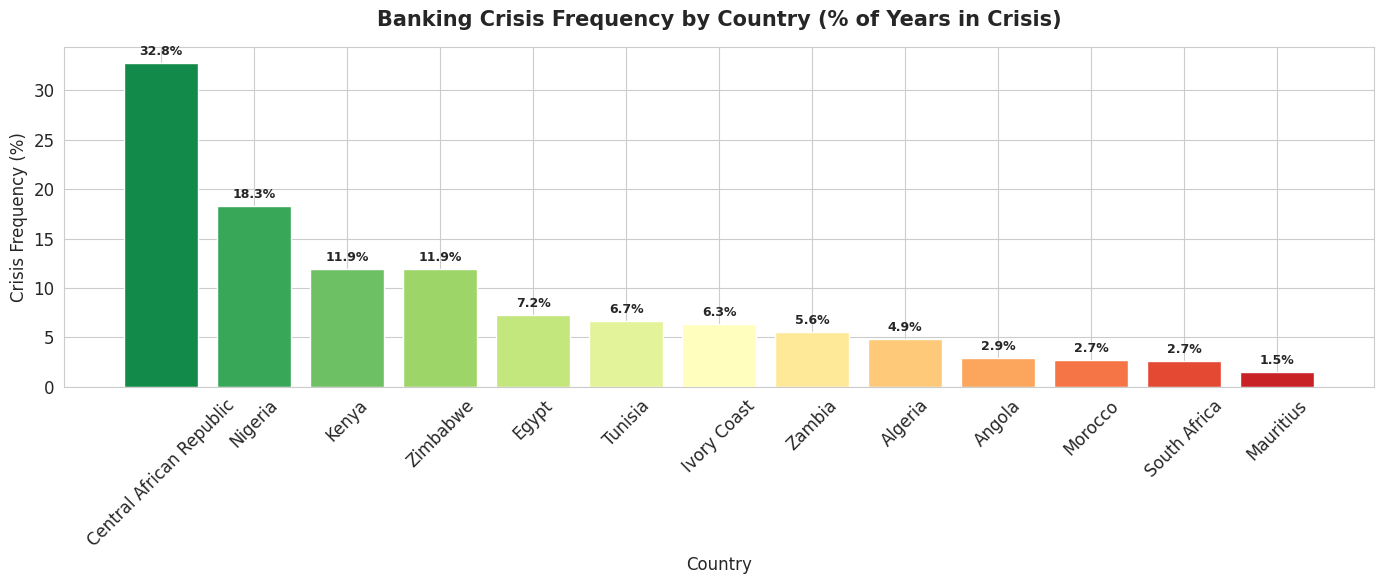


Countries with highest banking crisis rates:
country
Central African Republic    32.8
Nigeria                     18.3
Kenya                       11.9
Zimbabwe                    11.9
Egypt                        7.2
Name: banking_crisis_binary, dtype: float64


In [6]:
# --- Plot 1: Banking Crisis Frequency by Country ---
crisis_by_country = df_clean.groupby('country')['banking_crisis_binary'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(crisis_by_country.index, crisis_by_country.values,
              color=sns.color_palette('RdYlGn_r', len(crisis_by_country)))
ax.set_title('Banking Crisis Frequency by Country (% of Years in Crisis)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Crisis Frequency (%)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, crisis_by_country.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nCountries with highest banking crisis rates:')
print(crisis_by_country.head(5).round(1))

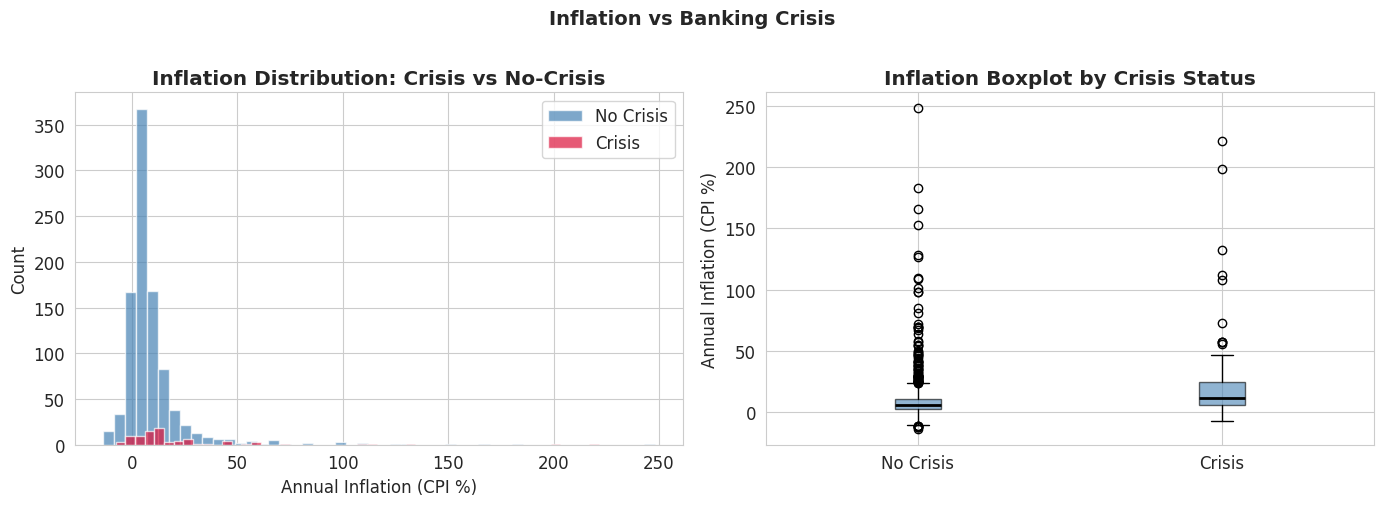

Avg inflation (No Crisis): 9.44%
Avg inflation (Crisis):    23.55%


In [7]:
# Plot: Inflation Distribution by Crisis Status
crisis_inf = df_clean[df_clean['banking_crisis_binary'] == 1]['inflation_annual_cpi']
no_crisis_inf = df_clean[df_clean['banking_crisis_binary'] == 0]['inflation_annual_cpi']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(no_crisis_inf, bins=50, alpha=0.7, color='steelblue', label='No Crisis', edgecolor='white')
axes[0].hist(crisis_inf, bins=50, alpha=0.7, color='crimson', label='Crisis', edgecolor='white')
axes[0].set_title('Inflation Distribution: Crisis vs No-Crisis', fontweight='bold')
axes[0].set_xlabel('Annual Inflation (CPI %)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot([no_crisis_inf, crisis_inf], labels=['No Crisis', 'Crisis'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Inflation Boxplot by Crisis Status', fontweight='bold')
axes[1].set_ylabel('Annual Inflation (CPI %)')

plt.suptitle('Inflation vs Banking Crisis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Avg inflation (No Crisis): {no_crisis_inf.mean():.2f}%')
print(f'Avg inflation (Crisis):    {crisis_inf.mean():.2f}%')

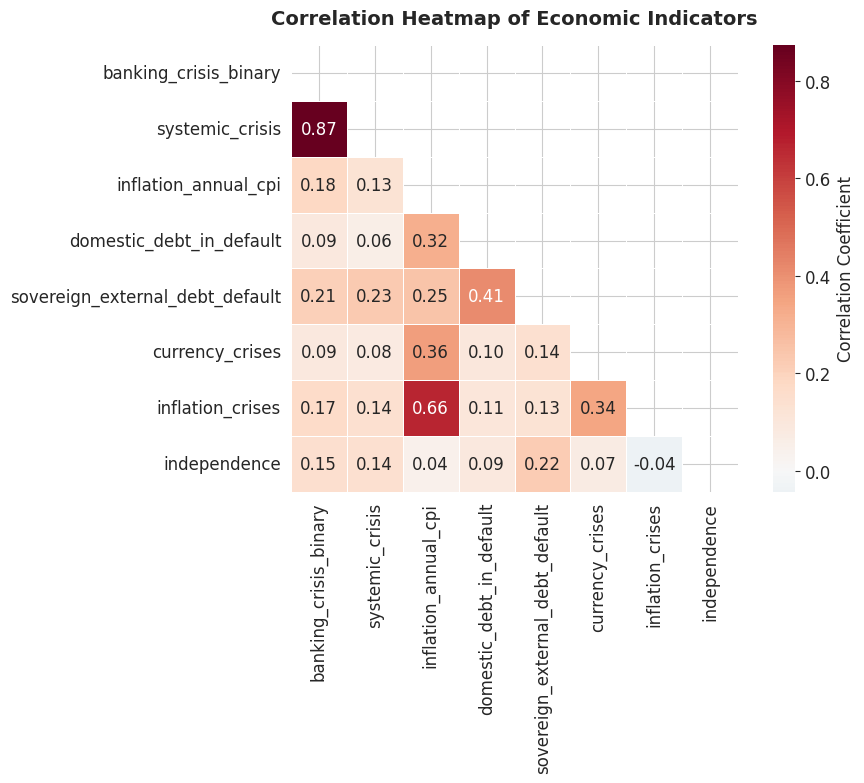

In [8]:
#  Plot 3: Correlation Heatmap 
numeric_cols = ['banking_crisis_binary', 'systemic_crisis', 'inflation_annual_cpi',
                'domestic_debt_in_default', 'sovereign_external_debt_default',
                'currency_crises', 'inflation_crises', 'independence']

corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Heatmap of Economic Indicators', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

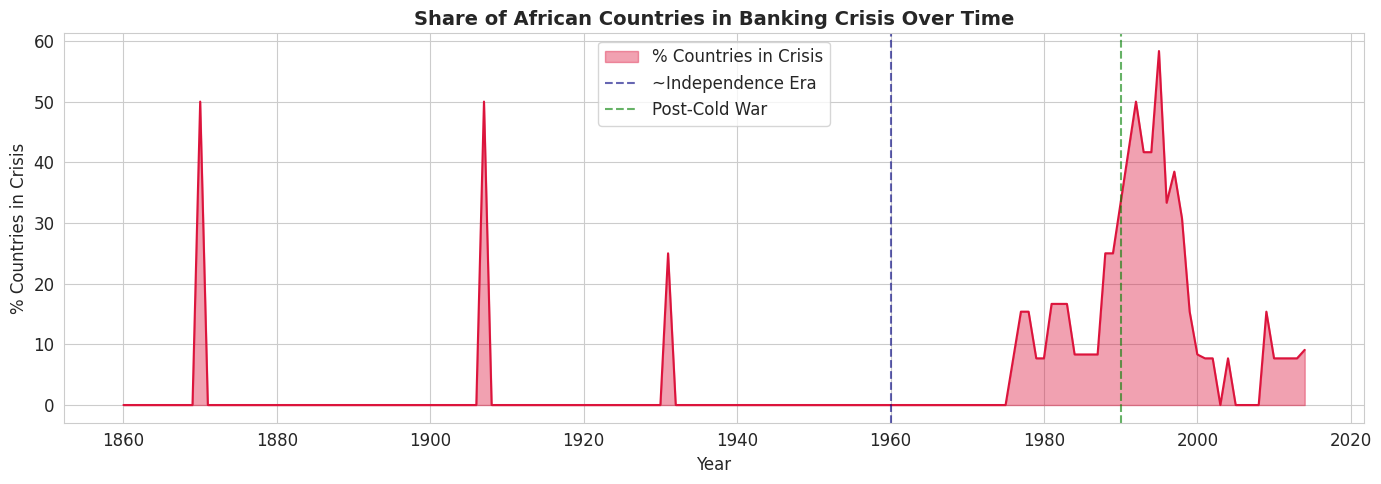

In [9]:
#  Plot 4: Crisis Stacked Area Over Time 
timeline = df_clean.groupby('year').agg(
    total=('banking_crisis_binary', 'count'),
    in_crisis=('banking_crisis_binary', 'sum')
).reset_index()
timeline['pct_crisis'] = timeline['in_crisis'] / timeline['total'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(timeline['year'], timeline['pct_crisis'], alpha=0.4, color='crimson', label='% Countries in Crisis')
ax.plot(timeline['year'], timeline['pct_crisis'], color='crimson', linewidth=1.5)
ax.axvline(1960, color='navy', linestyle='--', alpha=0.6, label='~Independence Era')
ax.axvline(1990, color='green', linestyle='--', alpha=0.6, label='Post-Cold War')
ax.set_title('Share of African Countries in Banking Crisis Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% Countries in Crisis')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Statistical Analysis

We now test whether the difference in inflation between crisis and non-crisis years is **statistically significant** using an **independent samples t-test**.

- **H₀ (Null Hypothesis):** Mean inflation is the same during crisis and non-crisis years
- **H₁ (Alternative Hypothesis):** Mean inflation is significantly higher during crisis years
- **Significance level:** α = 0.05

In [10]:
# T-Test: Inflation during crisis vs no-crisis
t_stat, p_value = stats.ttest_ind(crisis_inf, no_crisis_inf, equal_var=False)

print('=== Independent Samples T-Test: Inflation ===')
print(f'Crisis years:    Mean inflation: {crisis_inf.mean():.2f}% | Std: {crisis_inf.std():.2f}%')
print(f'No-crisis years: Mean inflation: {no_crisis_inf.mean():.2f}% | Std: {no_crisis_inf.std():.2f}%')
print(f'\nT-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.6f}')
print()
if p_value < 0.05:
    print('Result: We REJECT the null hypothesis.')
    print('Inflation is significantly higher during banking crisis years (p < 0.05).')
else:
    print('Result: We FAIL to reject the null hypothesis.')

=== Independent Samples T-Test: Inflation ===
Crisis years:    Mean inflation: 23.55% | Std: 38.57%
No-crisis years: Mean inflation: 9.44% | Std: 18.60%

T-statistic: 3.3189
P-value:     0.001324

Result: We REJECT the null hypothesis.
Inflation is significantly higher during banking crisis years (p < 0.05).


In [11]:
#  Chi-square test: Sovereign debt default vs Banking crisis 
contingency = pd.crosstab(df_clean['sovereign_external_debt_default'],
                          df_clean['banking_crisis_binary'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print('=== Chi-Square Test: Sovereign Debt Default vs Banking Crisis ===')
print('\nContingency Table:')
print(contingency.rename(columns={0: 'No Crisis', 1: 'Crisis'},
                         index={0: 'No Default', 1: 'Defaulted'}))
print(f'\nChi2 statistic: {chi2:.4f}')
print(f'P-value:        {p_chi2:.6f}')
print(f'Degrees of freedom: {dof}')
if p_chi2 < 0.05:
    print('\n Sovereign debt default and banking crisis are significantly associated (p < 0.05).')

# Crisis rate by debt default status
crisis_rate_default = df_clean.groupby('sovereign_external_debt_default')['banking_crisis_binary'].mean() * 100
print(f'\nCrisis rate when NO default: {crisis_rate_default[0]:.1f}%')
print(f'Crisis rate when DEFAULT:    {crisis_rate_default[1]:.1f}%')

=== Chi-Square Test: Sovereign Debt Default vs Banking Crisis ===

Contingency Table:
banking_crisis_binary            No Crisis  Crisis
sovereign_external_debt_default                   
No Default                             835      51
Defaulted                              118      33

Chi2 statistic: 42.7759
P-value:        0.000000
Degrees of freedom: 1

 Sovereign debt default and banking crisis are significantly associated (p < 0.05).

Crisis rate when NO default: 5.8%
Crisis rate when DEFAULT:    21.9%


## 7. Predictive Modeling

We upgrade the model in three ways, each aimed at making the prediction claim honest:

1. **Lagged features.** `exch_usd`, `inflation_annual_cpi`, `domestic_debt_in_default`, and `sovereign_external_debt_default` are shifted one year back per country (`_lag1`). The model predicts a banking crisis in year *t* using only what was known at the end of year *t-1*, so this is now a genuine early-warning setup rather than a same-year association. `systemic_crisis`, `currency_crises`, and `inflation_crises` remain excluded entirely, since they are crisis indicators themselves, not leading indicators.
2. **Group-aware cross-validation.** With only about 85 crisis-years total, a single train/test split (as used originally) is noisy: whichever few crisis cases land in the test set swing the AUC a lot, and a random row-level split lets the same country appear in both train and test. We use `StratifiedGroupKFold` (grouped by `country`) so each fold holds out entire countries, and report the mean and standard deviation of ROC-AUC and PR-AUC across 5 folds.
3. **Baseline plus a second model.** A majority-class `DummyClassifier` baseline and a `RandomForestClassifier` are added alongside logistic regression, so the logistic regression's performance can be judged against "predicting nothing" and against a non-linear alternative.

We also report **PR-AUC** (average precision) alongside ROC-AUC, since with crises at only about 8% of rows, ROC-AUC can look reasonable even when precision is poor. PR-AUC is the more honest metric for this class imbalance.

In [12]:
# Step 7: Build lagged features (one year back, per country) so the model forecasts
# a crisis in year t from what was actually observable at the end of year t-1.
df_clean = df_clean.sort_values(['country', 'year'])

lag_cols = ['exch_usd', 'inflation_annual_cpi',
            'domestic_debt_in_default', 'sovereign_external_debt_default']

for col in lag_cols:
    df_clean[f'{col}_lag1'] = df_clean.groupby('country')[col].shift(1)

# Drop each country's first year in the cleaned data (no prior-year value to lag from)
df_model = df_clean.dropna(subset=[f'{c}_lag1' for c in lag_cols]).copy()

features = [f'{c}_lag1' for c in lag_cols] + ['independence']

print(f'Rows available for lagged modeling: {len(df_model)} (of {len(df_clean)} cleaned rows)')
print(f'Crisis rate in modeling set: {df_model["banking_crisis_binary"].mean()*100:.1f}%')
print(f'\nFeatures used: {features}')

Rows available for lagged modeling: 1024 (of 1037 cleaned rows)
Crisis rate in modeling set: 8.1%

Features used: ['exch_usd_lag1', 'inflation_annual_cpi_lag1', 'domestic_debt_in_default_lag1', 'sovereign_external_debt_default_lag1', 'independence']


In [13]:
# Step 8: Baseline + model comparison via group-aware cross-validation
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score

X_all = df_model[features].fillna(0)
y_all = df_model['banking_crisis_binary']
groups_all = df_model['country']

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

candidate_models = {
    'Baseline (majority class)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=5, class_weight='balanced', random_state=42
    ),
}

cv_rows = []
for name, clf in candidate_models.items():
    scores = cross_validate(
        clf, X_all, y_all, cv=cv, groups=groups_all,
        scoring=['roc_auc', 'average_precision']
    )
    cv_rows.append({
        'Model': name,
        'ROC-AUC (mean)': scores['test_roc_auc'].mean(),
        'ROC-AUC (std)': scores['test_roc_auc'].std(),
        'PR-AUC (mean)': scores['test_average_precision'].mean(),
        'PR-AUC (std)': scores['test_average_precision'].std(),
    })

cv_results = pd.DataFrame(cv_rows).round(3)
print('=== 5-Fold Group Cross-Validation (grouped by country) ===')
cv_results

=== 5-Fold Group Cross-Validation (grouped by country) ===


,Model,ROC-AUC (mean),ROC-AUC (std),PR-AUC (mean),PR-AUC (std)
0,Baseline (majority class),0.500,0.000,0.083,0.039
1,Logistic Regression,0.812,0.048,0.254,0.081
2,Random Forest,0.794,0.083,0.252,0.098


In [14]:
# Step 9: A single group-aware train/test split, used only to produce the plots below.
# The CV table above is the trustworthy performance estimate; this split is for visualization
# and coefficient interpretation, and (with few crisis cases per country) is noisier on its own.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups_all))

X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]

print(f'Test countries (fully held out): {sorted(groups_all.iloc[test_idx].unique())}')

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Fit model (class_weight='balanced' since banking crises are rare, ~8% of rows)
model = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print(f'\nAccuracy:  {accuracy_score(y_test, y_pred)*100:.1f}%')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, y_prob):.4f}')
print()
print('=== Classification Report (held-out countries) ===')
print(classification_report(y_test, y_pred, target_names=['No Crisis', 'Crisis']))

Test countries (fully held out): ['Algeria', 'South Africa', 'Zambia']

Accuracy:  84.5%
ROC-AUC:   0.8512
PR-AUC:    0.1439

=== Classification Report (held-out countries) ===
              precision    recall  f1-score   support

   No Crisis       0.98      0.86      0.91       254
      Crisis       0.12      0.50      0.20        10

    accuracy                           0.84       264
   macro avg       0.55      0.68      0.56       264
weighted avg       0.95      0.84      0.89       264



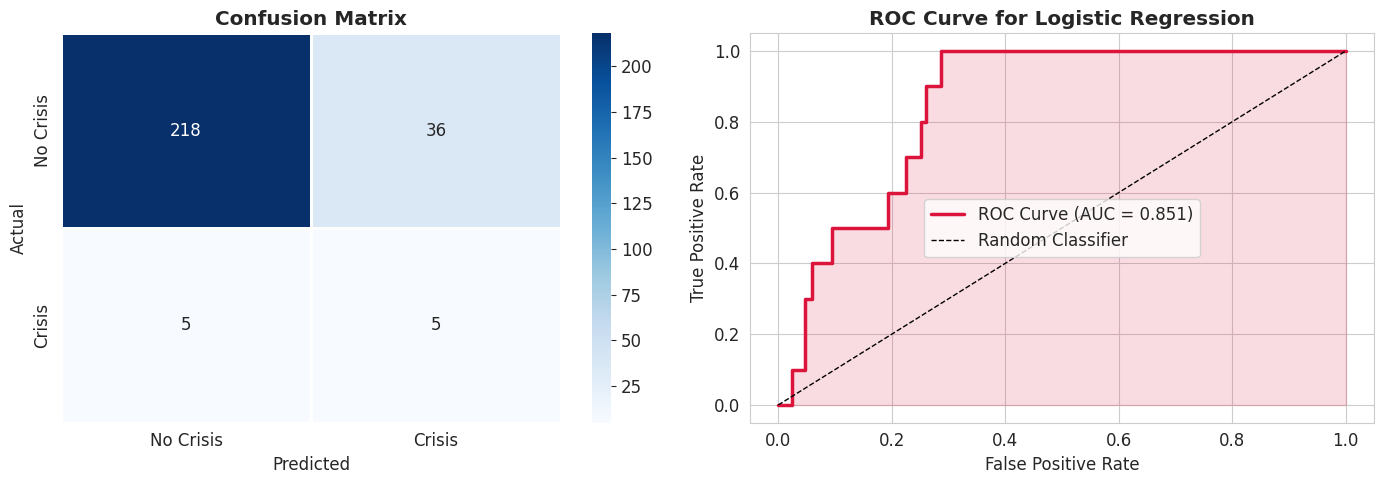

In [15]:
# Plot 5: Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Crisis', 'Crisis'],
            yticklabels=['No Crisis', 'Crisis'],
            linewidths=1)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 6: ROC Curve 
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='crimson', lw=2.5, label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='crimson')
axes[1].set_title('ROC Curve for Logistic Regression', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

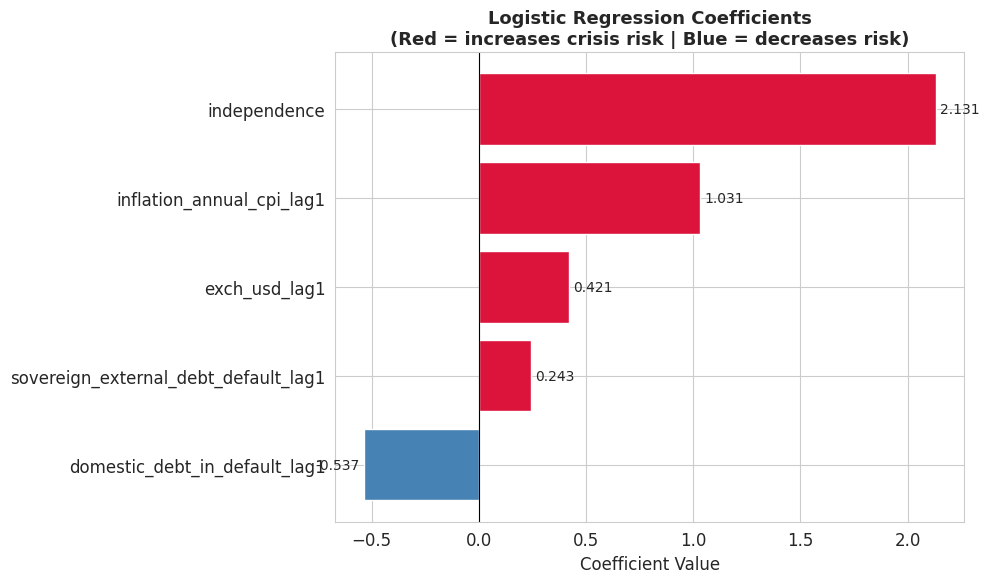


Top risk factors for banking crisis:
                             Feature  Coefficient
                        independence     2.130827
           inflation_annual_cpi_lag1     1.031378
                       exch_usd_lag1     0.420951
sovereign_external_debt_default_lag1     0.243445
       domestic_debt_in_default_lag1    -0.536530


In [16]:
# Plot 7: Feature Importance (Logistic Regression Coefficients) 
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')

colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(Red = increases crisis risk | Blue = decreases risk)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Coefficient Value')
for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.show()

print('\nTop risk factors for banking crisis:')
print(coef_df.sort_values('Coefficient', ascending=False)[['Feature', 'Coefficient']].to_string(index=False))

## 8. Conclusion

### Key Findings

**1. Inflation is a strong predictor of banking crises.**  
The t-test confirmed (p < 0.05) that inflation is significantly higher during banking crisis years. Countries experiencing hyperinflation are far more vulnerable.

**2. Sovereign debt default is closely linked to banking crises.**  
The chi-square test showed a significant association between sovereign debt defaults and banking crises. Countries that defaulted on external debt had a much higher crisis rate.

**3. Lagged inflation, currency depreciation, and independence status are the leading predictors, measured one year ahead of the crisis.**  
Using only prior-year (`_lag1`) values of inflation, exchange rate, and debt-default status, and with `systemic_crisis`, `currency_crises`, and `inflation_crises` excluded entirely as leakage, the logistic regression's strongest positive coefficients are `independence` (2.13) and `inflation_annual_cpi_lag1` (1.03), followed by `exch_usd_lag1` (0.42) and `sovereign_external_debt_default_lag1` (0.24). `domestic_debt_in_default_lag1` is slightly negative, likely reflecting how few observations combine a domestic default with a following-year banking crisis in this sample. This is a genuine early-warning result: last year's inflation and currency pressure predict *next* year's crisis risk.

**4. Against a proper baseline and a second model, logistic regression holds up, and the honest numbers are much lower than the original (leaked) result.**  
5-fold, country-grouped cross-validation gives the following: majority-class baseline ROC-AUC 0.500 and PR-AUC 0.083 (the baseline PR-AUC equals the crisis rate, as expected); Logistic Regression ROC-AUC 0.812 (std 0.048) and PR-AUC 0.254 (std 0.081); Random Forest ROC-AUC 0.794 (std 0.083) and PR-AUC 0.252 (std 0.098). Both real models clear the baseline by a wide margin on both metrics, and the simpler logistic regression is at least as good as the Random Forest here. Still, a PR-AUC around 0.25 against an 8% base rate means precision is modest: this is a genuine signal, not a reliable crisis-caller. On a single held-out group of countries (Algeria, South Africa, Zambia) the model reaches ROC-AUC 0.851 but PR-AUC only 0.144, with crisis-class precision of just 0.12 at recall 0.50. That gap is a reminder that single-split numbers on rare events are noisy, which is exactly why the 5-fold CV table is the number to trust, not this one split.

**5. Historical patterns matter.**  
Crisis frequency peaked in the 1980s-1990s, coinciding with post-independence economic restructuring, IMF structural adjustment programs, and global commodity price shocks.

---

### Limitations

- **Data gaps:** Not all years are represented for all countries, some data is sparse.
- **Class imbalance:** Banking crises are relatively rare (about 8% of country-years in the lagged modeling set), so `class_weight='balanced'` was used to keep both models from ignoring the crisis class. Even so, PR-AUC (about 0.25) shows precision on the crisis class is still limited by how few crisis examples exist.
- **Small crisis count relative to countries:** With about 13 countries and about 83 crisis-years total, grouped 5-fold CV still leaves each fold's estimate somewhat noisy (ROC-AUC standard deviation of 0.05 to 0.08). More data or more countries would tighten this.
- **Correlation is not causation:** While inflation and debt default are associated with crises, we cannot conclude they directly cause them without deeper causal analysis.
- **Outdated data:** The dataset ends in 2014, missing recent crises and the COVID-19 economic shock.
- **13 countries only:** This is not a full picture of Africa's 54 nations.

---

### What I Learned

This project taught me two hard lessons about honest model evaluation, back to back. First, my original model included `systemic_crisis`, `currency_crises`, and `inflation_crises` as predictors. These are crisis flags nearly coincident with the `banking_crisis` target, and they produced an unrealistic 0.98 AUC that should have been a red flag rather than a success. Second, even after removing those columns, evaluating same-year indicators on a single random train/test split was still generous: it doesn't test whether the model can forecast ahead of time, and a single split on a rare event is noisy no matter how it's drawn. Rebuilding the pipeline with lagged (`t-1`) features, a majority-class baseline, a second model (Random Forest), and 5-fold cross-validation grouped by country brought the honest numbers into view: ROC-AUC around 0.81 and PR-AUC around 0.25, comfortably above baseline but far from a reliable crisis-caller. That's a much more defensible foundation, and a good reminder to always ask not just whether a feature could leak the label, but also whether the evaluation setup would survive a skeptical second look. With more data and true real-time indicators, this lagged, cross-validated approach could be extended toward a genuine early-warning system for African banking crises.